In [251]:
import pandas as pd
import joblib
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [252]:
df_old = pd.read_csv('../../../../data/preprocessed/selected_features_dataset_V2.csv')

In [253]:
df_old.columns.to_list()

['address_locality',
 'address_line_2',
 'near_Koh_Pich_in_km',
 'near_Bassac_Lane_in_km',
 'near_Royal_Palace_in_km',
 'near_Phnom_Penh_Airport_in_km',
 'n_secondary_school_in_3km_to_5km',
 'n_primary_school_5km',
 'n_primary_school_in_3km_to_5km',
 'n_university_in_2km_to_3km',
 'n_university_in_3km_to_5km',
 'n_resturant_in_1km',
 'n_super_market_5km',
 'n_super_market_in_1km_to_2km',
 'n_bank_5km',
 'price_per_m2']

In [254]:
df = pd.read_csv('../../../../data/processed/100k.csv')
X = df.drop(['price_per_m2'], axis=1)
y = df['price_per_m2']

In [255]:
LABEL_ENCODERS_PATH = "../../../../data/processed/label_encoders_v2.pkl"
SELECTED_FEATURES = ['address_locality',
                    'address_line_2',
                    'near_Koh_Pich_in_km',
                    'near_Bassac_Lane_in_km',
                    'near_Royal_Palace_in_km',
                    'near_Phnom_Penh_Airport_in_km',
                    'n_secondary_school_in_3km_to_5km',
                    'n_primary_school_5km',
                    'n_primary_school_in_3km_to_5km',
                    'n_university_in_2km_to_3km',
                    'n_university_in_3km_to_5km',
                    'n_resturant_in_1km',
                    'n_super_market_5km',
                    'n_super_market_in_1km_to_2km',
                    'n_bank_5km']

In [256]:
label_encoders = joblib.load(LABEL_ENCODERS_PATH)


In [257]:
print(label_encoders)

{'address_subdivision': LabelEncoder(), 'address_locality': LabelEncoder(), 'address_line_2': LabelEncoder(), 'h_id': LabelEncoder()}


In [258]:
features = X.copy()

In [259]:
encoded_values = {}

for col, encoder in label_encoders.items():
    if col in features:
        def encode_value(val):
            if val in encoder.classes_:
                return encoder.transform([val])[0]
            else:
                return -1  # Handle unseen label
        
        # Apply encoding row-wise
        features[col] = features[col].apply(encode_value)
        encoded_values[col] = features[col]


In [260]:
X.head()

,address_subdivision,address_locality,address_line_2,h_id,land_area,price,longitude,latitude,near_Koh_Pich_in_km,Koh_Pich_nearest,...,f_road,f_secondary,f_service,f_steps,f_tertiary,f_track,f_trunk,f_trunk_link,f_unclassified,f_unused
0,Phnom Penh,Praek Pnov,Samraong,886580d009fffff,132,132,104.83,11.72,22,0,...,0,0,0,0,0,0,0,0,0,0
1,Phnom Penh,Pur SenChey,Kamboul,8865846ea7fffff,174,174,104.74,11.55,21,0,...,0,0,0,0,1,1,0,0,1,0
2,Phnom Penh,Chraoy Chongvar,Preaek Ta Sek,886580d26dfffff,150,150,104.88,11.68,15,0,...,0,0,1,0,0,0,0,0,0,0
3,Phnom Penh,Pur SenChey,Ovlaok,8865846c3bfffff,152,152,104.76,11.58,20,0,...,0,0,0,0,0,0,0,0,0,0
4,Phnom Penh,Pur SenChey,Boeng Thum,8865846521fffff,96,96,104.77,11.48,20,0,...,0,0,1,0,0,0,0,0,0,0


In [261]:
features.head()

,address_subdivision,address_locality,address_line_2,h_id,land_area,price,longitude,latitude,near_Koh_Pich_in_km,Koh_Pich_nearest,...,f_road,f_secondary,f_service,f_steps,f_tertiary,f_track,f_trunk,f_trunk_link,f_unclassified,f_unused
0,0,6,73,0,132,132,104.83,11.72,22,0,...,0,0,0,0,0,0,0,0,0,0
1,0,8,25,684,174,174,104.74,11.55,21,0,...,0,0,0,0,1,1,0,0,1,0
2,0,2,66,49,150,150,104.88,11.68,15,0,...,0,0,1,0,0,0,0,0,0,0
3,0,8,43,518,152,152,104.76,11.58,20,0,...,0,0,0,0,0,0,0,0,0,0
4,0,8,9,270,96,96,104.77,11.48,20,0,...,0,0,1,0,0,0,0,0,0,0


In [262]:
features = features[SELECTED_FEATURES]

In [263]:
def predict_with_models(X_processed, models):
    predictions = {}
    for name, model in models.items():
        predictions[name] = model.predict(X_processed)
    return pd.DataFrame(predictions)

In [264]:
lr_model = joblib.load("../../../../models/linear_regression/linear_regression_model_v3.joblib")
rf_model = joblib.load("../../../../models/random_forest/random_forest_model_v5_label.joblib")
xgb_model = joblib.load("../../../../models/xgboost/xgboost_model_label_v6.joblib")
svr_model = joblib.load("../../../../models/svr/svr_model_label_v4.joblib")
knn_model = joblib.load("../../../../models/knn/knn_model_v1.joblib")
br_model = joblib.load("../../../../models/bayesian_ridge/bayesian_ridge_model_label_v1.joblib")

In [265]:
models = {
    "LR": lr_model,
    "RF": rf_model,
    "XGBoost": xgb_model,
    "SVR": svr_model,
    "KNN": knn_model,
    "BR": br_model
}

In [266]:
preds_df = predict_with_models(features, models)

In [267]:
preds_df

,LR,RF,XGBoost,SVR,KNN,BR
0,-167.23,87.83,359.66,243.81,128.57,22.04
1,113.77,171.45,413.13,119.42,441.78,275.20
2,487.87,309.23,454.71,253.93,401.98,483.64
3,174.31,80.94,391.62,126.49,75.41,298.49
4,138.52,199.07,441.44,233.13,130.74,391.24
...,...,...,...,...,...,...
99995,38.31,104.03,418.69,146.89,107.47,249.59
99996,819.49,1289.86,959.13,888.04,807.30,786.68
99997,981.62,525.76,680.10,492.35,499.76,802.48
99998,1221.11,1136.79,1203.75,1299.89,1158.74,1265.07


In [268]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # Avoid division by zero
    return np.mean(np.abs((y_true - y_pred) / np.clip(y_true, 1e-8, None))) * 100

def evaluate_models(y_true, predictions_df):
    results = []

    for model_name in predictions_df.columns:
        y_pred = predictions_df[model_name]
        mae = mean_absolute_error(y_true, y_pred)
        mse = mean_squared_error(y_true, y_pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_true, y_pred)
        mape = mean_absolute_percentage_error(y_true, y_pred)

        results.append({
            'Model': model_name,
            'MAE': mae,
            'MSE': mse,
            'RMSE': rmse,
            'R2': r2,
            'MAPE (%)': mape
        })

    return pd.DataFrame(results).sort_values(by='RMSE')


In [269]:
evaluation_results = evaluate_models(y, preds_df)

In [270]:
print(evaluation_results)

     Model    MAE       MSE   RMSE   R2  MAPE (%)
1       RF 240.53 174657.34 417.92 0.88     27.74
4      KNN 256.47 202587.17 450.10 0.86     28.88
2  XGBoost 306.55 217778.50 466.67 0.85     69.77
3      SVR 280.22 234407.77 484.16 0.84     33.06
0       LR 339.92 267198.37 516.91 0.82     57.50
5       BR 324.45 272629.71 522.14 0.81     49.21


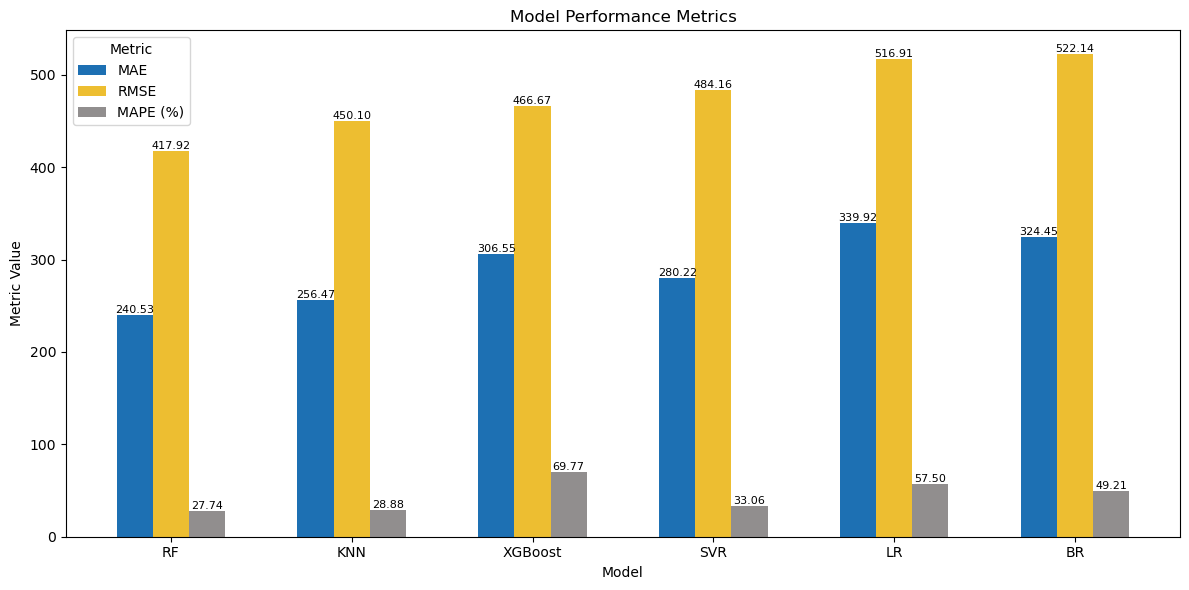

In [310]:
import matplotlib.pyplot as plt
import pandas as pd

# Your evaluation results DataFrame
# Make sure `evaluation_results` is already defined and contains columns: Model, MAE, MSE, RMSE, R2, MAPE (%)
metrics_to_plot = ['MAE', 'RMSE', 'MAPE (%)']

# Convert wide to long format for plotting
df_long = evaluation_results.melt(id_vars='Model', value_vars=metrics_to_plot,
                                  var_name='Metric', value_name='Value')

# Sort models for consistent display
models = df_long['Model'].unique()
metrics = df_long['Metric'].unique()

# Define bar width and positions
bar_width = 0.2
x = range(len(models))

# Plotting
plt.figure(figsize=(12, 6))
custom_colors = {
    'MAE': "#1D70B3",       # Blue
    'RMSE': "#EDBE31",      # Green
    'MAPE (%)': "#918E8E"   # Purple
}

for i, metric in enumerate(metrics):
    data = df_long[df_long['Metric'] == metric]
    x_positions = [pos + i * bar_width for pos in x]
    bars = plt.bar(x_positions, data['Value'], width=bar_width, label=metric, color=custom_colors[metric])

    # Add number labels on top of bars
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height,
                 f'{height:.2f}', ha='center', va='bottom', fontsize=8)

# Configure x-axis
plt.xticks([pos + bar_width * (len(metrics) - 1) / 2 for pos in x], models)
plt.xlabel('Model')
plt.ylabel('Metric Value')
plt.title('Model Performance Metrics')
plt.legend(title='Metric')
plt.tight_layout()
plt.show()


In [271]:
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / np.clip(y_true, 1e-8, None))) * 100

def evaluate_by_location(X_raw, y_true, predictions_df, location_col='address_locality'):
    results = []

    for model_name in predictions_df.columns:
        df = X_raw.copy()
        df['y_true'] = y_true
        df['y_pred'] = predictions_df[model_name]
        df['abs_error'] = np.abs(df['y_true'] - df['y_pred'])
        df['squared_error'] = (df['y_true'] - df['y_pred']) ** 2
        df['abs_pct_error'] = np.abs((df['y_true'] - df['y_pred']) / np.clip(df['y_true'], 1e-8, None)) * 100

        grouped = df.groupby(location_col).agg(
            count=('y_true', 'size'),
            MAE=('abs_error', 'mean'),
            MSE=('squared_error', 'mean'),
            RMSE=('squared_error', lambda x: np.sqrt(np.mean(x))),
            MAPE=('abs_pct_error', 'mean')
        ).reset_index()

        # Calculate R2 for each group, safely skipping groups with NaNs or no variation in y_true
        r2_values = []
        for loc in grouped[location_col]:
            group = df[df[location_col] == loc][['y_true', 'y_pred']].dropna()
            if not group.empty and group['y_true'].nunique() > 1:
                r2 = r2_score(group['y_true'], group['y_pred'])
            else:
                r2 = np.nan
            r2_values.append(r2)

        grouped['R2'] = r2_values
        grouped['Model'] = model_name
        results.append(grouped)

    return pd.concat(results, ignore_index=True)

In [272]:
grouped_by_location_df = evaluate_by_location(X, y, preds_df)

knn_results = grouped_by_location_df[grouped_by_location_df['Model'] == 'KNN']

In [273]:
knn_results

,address_locality,count,MAE,MSE,RMSE,MAPE,R2,Model
48,Chamkar Mon,1980,1026.35,1703570.94,1305.21,18.19,-0.13,KNN
49,Chbar Ampov,13184,278.45,222661.31,471.87,39.73,0.09,KNN
50,Chraoy Chongvar,11847,283.99,244342.71,494.31,35.43,0.54,KNN
51,Dangkao,18414,177.48,75549.92,274.86,31.35,0.52,KNN
52,Doun Penh,1451,1176.35,2457015.11,1567.49,19.09,0.27,KNN
53,Mean Chey,4173,413.00,291073.17,539.51,19.73,-0.02,KNN
54,Praek Pnov,13910,122.54,33560.44,183.20,29.48,0.58,KNN
55,Prampir Meakkakra,377,791.25,883074.79,939.72,15.72,0.03,KNN
56,Pur SenChey,21808,161.04,52215.61,228.51,24.39,0.87,KNN
57,Russey Keo,4055,424.36,396959.49,630.05,29.05,-0.25,KNN


In [274]:
from sklearn.model_selection import train_test_split

In [275]:
X_old = df_old.drop(['price_per_m2'], axis=1)
y_old = df_old['price_per_m2']
X_train_old, X_test_old, y_train_old, y_test_old = train_test_split(X_old, y_old, test_size=0.2, random_state=42)

In [276]:
preds_df_old = predict_with_models(X_test_old, models)

In [277]:
evaluation_results_old = evaluate_models(y_test_old, preds_df_old)

In [278]:
evaluation_results_old

,Model,MAE,MSE,RMSE,R2,MAPE (%)
1,RF,325.23,315203.72,561.43,0.89,38.78
2,XGBoost,442.58,388278.67,623.12,0.87,121.07
4,KNN,362.51,388930.65,623.64,0.87,40.79
3,SVR,396.93,431959.73,657.24,0.86,45.70
5,BR,438.84,455675.37,675.04,0.85,73.20
0,LR,488.54,547870.89,740.18,0.82,87.24


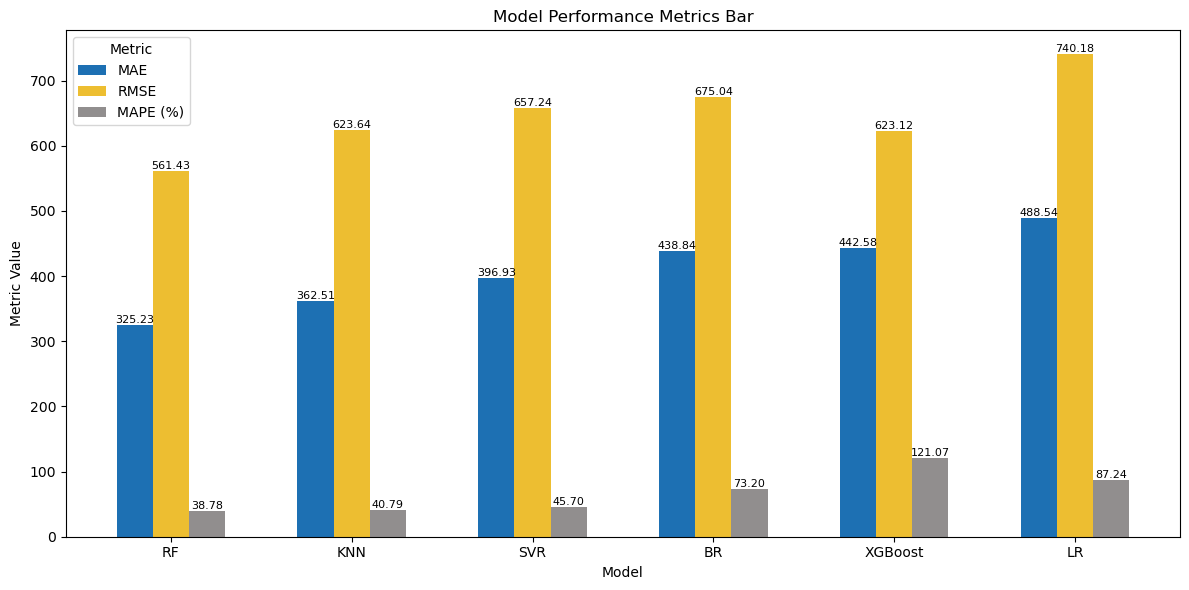

In [313]:
import matplotlib.pyplot as plt
import pandas as pd

# Select metrics
metrics_to_plot = ['MAE', 'RMSE', 'MAPE (%)']

# Sort evaluation_results_old by MAE
sorted_df = evaluation_results_old.sort_values(by='MAE', ascending=True)
sorted_models = sorted_df['Model'].tolist()

# Melt for long format plotting
df_long = sorted_df.melt(id_vars='Model', value_vars=metrics_to_plot,
                         var_name='Metric', value_name='Value')

# Ensure model order is preserved
df_long['Model'] = pd.Categorical(df_long['Model'], categories=sorted_models, ordered=True)

# Bar setup
bar_width = 0.2
models = df_long['Model'].cat.categories.tolist()
metrics = df_long['Metric'].unique()
x = list(range(len(models)))

# Colors
custom_colors = {
    'MAE': "#1D70B3",       # Blue
    'RMSE': "#EDBE31",      # Yellow-Gold
    'MAPE (%)': "#918E8E"   # Gray
}

# Plot
plt.figure(figsize=(12, 6))
for i, metric in enumerate(metrics):
    data = df_long[df_long['Metric'] == metric]
    x_positions = [pos + i * bar_width for pos in x]
    bars = plt.bar(x_positions, data['Value'], width=bar_width,
                   label=metric, color=custom_colors[metric])

    # Add value labels
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height,
                 f'{height:.2f}', ha='center', va='bottom', fontsize=8)

# X-axis and labels
plt.xticks([pos + bar_width * (len(metrics) - 1) / 2 for pos in x], models)
plt.xlabel('Model')
plt.ylabel('Metric Value')
plt.title('Model Performance Metrics Bar')
plt.legend(title='Metric')
plt.tight_layout()
plt.show()


In [279]:
y_test_old.isnull().sum()

0

In [280]:
grouped_by_location_df_old = evaluate_by_location(X_test_old, y_test_old, preds_df_old)

knn_results = grouped_by_location_df_old[grouped_by_location_df_old['Model'] == 'KNN']

In [281]:
encoder = label_encoders['address_locality']
knn_results['address_locality'] = encoder.inverse_transform(knn_results['address_locality'].astype(int))

C:\Users\User\AppData\Local\Temp\ipykernel_14484\2699892500.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  knn_results['address_locality'] = encoder.inverse_transform(knn_results['address_locality'].astype(int))


In [282]:
total_count = knn_results['count'].sum()
print("Total count:", total_count)


Total count: 1812


In [283]:
knn_results

,address_locality,count,MAE,MSE,RMSE,MAPE,R2,Model
48,Chamkar Mon,158,3001.41,11687355.04,3418.68,67.94,-10.22,KNN
49,Chbar Ampov,156,2753.42,9937234.03,3152.34,563.35,-140.22,KNN
50,Chraoy Chongvar,141,1402.87,2870710.01,1694.32,88.26,-0.98,KNN
51,Dangkao,290,2793.04,15215997.51,3900.77,1736.87,-1194.23,KNN
52,Doun Penh,108,3009.42,13069463.12,3615.17,61.20,-4.49,KNN
53,Mean Chey,85,2014.40,4951561.67,2225.21,73.17,-6.55,KNN
54,Praek Pnov,162,NaN,NaN,NaN,NaN,NaN,KNN
55,Prampir Meakkakra,43,2761.83,10452555.37,3233.04,61.67,-8.64,KNN
56,Pur SenChey,357,630.55,710743.10,843.06,62.03,0.18,KNN
57,Russey Keo,80,NaN,NaN,NaN,NaN,NaN,KNN


In [284]:
knn_evaluation_results_old = evaluation_results_old[evaluation_results_old['Model'] == 'KNN']
knn_evaluation_results_old

,Model,MAE,MSE,RMSE,R2,MAPE (%)
4,KNN,362.51,388930.65,623.64,0.87,40.79


In [285]:
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score

def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / np.clip(y_true, 1e-8, None))) * 100

def evaluate_by_price_range(X_raw, y_true, predictions_df, price_col='y_true'):
    results = []

    # Define price bins (you can adjust bins for better accuracy)
    price_bins = [40, 100, 200, 500, 1000, 2000, 4000, 6000, 8000, 10000, 12000]
    price_labels = ['40-100', '100-200', '200-500', '500-1k', '1k-2k', '2k-4k', '4k-6k', '6k-8k', '8k-10k', '10k-12k']

    for model_name in predictions_df.columns:
        df = X_raw.copy()
        df['y_true'] = y_true
        df['y_pred'] = predictions_df[model_name]
        df['abs_error'] = np.abs(df['y_true'] - df['y_pred'])
        df['squared_error'] = (df['y_true'] - df['y_pred']) ** 2
        df['abs_pct_error'] = np.abs((df['y_true'] - df['y_pred']) / np.clip(df['y_true'], 1e-8, None)) * 100

        # Assign price ranges to y_true
        df['price_range'] = pd.cut(df['y_true'], bins=price_bins, labels=price_labels, include_lowest=True)

        grouped = df.groupby('price_range').agg(
            count=('y_true', 'size'),
            MAE=('abs_error', 'mean'),
            MSE=('squared_error', 'mean'),
            RMSE=('squared_error', lambda x: np.sqrt(np.mean(x))),
            MAPE=('abs_pct_error', 'mean')
        ).reset_index()

        # Calculate R2 for each price range, handling NaNs and constant values
        r2_values = []
        for pr in grouped['price_range']:
            group = df[df['price_range'] == pr][['y_true', 'y_pred']].dropna()
            if not group.empty and group['y_true'].nunique() > 1:
                r2 = r2_score(group['y_true'], group['y_pred'])
            else:
                r2 = np.nan
            r2_values.append(r2)

        grouped['R2'] = r2_values
        grouped['Model'] = model_name
        results.append(grouped)

    return pd.concat(results, ignore_index=True)


In [286]:
grouped_by_price_df = evaluate_by_price_range(X_test_old, y_test_old, preds_df)
knn_price_results = grouped_by_price_df[grouped_by_price_df['Model'] == 'KNN']

C:\Users\User\AppData\Local\Temp\ipykernel_14484\2262972338.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('price_range').agg(
C:\Users\User\AppData\Local\Temp\ipykernel_14484\2262972338.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('price_range').agg(
C:\Users\User\AppData\Local\Temp\ipykernel_14484\2262972338.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gro

In [287]:
knn_price_results

,price_range,count,MAE,MSE,RMSE,MAPE,R2,Model
40,40-100,167,1253.32,3593329.69,1895.61,1860.72,-12235.96,KNN
41,100-200,270,1151.15,3171712.18,1780.93,805.94,-4097.35,KNN
42,200-500,310,880.63,2432230.35,1559.56,286.41,-307.29,KNN
43,500-1k,217,1050.45,2467862.42,1570.94,152.35,-130.96,KNN
44,1k-2k,230,1274.80,2348315.76,1532.42,86.95,-32.36,KNN
45,2k-4k,389,2072.28,5259986.68,2293.47,69.72,-15.70,KNN
46,4k-6k,174,3657.51,15589153.98,3948.31,74.34,-49.12,KNN
47,6k-8k,32,5867.33,35537074.58,5961.30,88.86,-123.44,KNN
48,8k-10k,2,6458.77,43768045.61,6615.74,78.09,-482.11,KNN
49,10k-12k,0,NaN,NaN,NaN,NaN,NaN,KNN


In [288]:
def evaluate_by_price_quantiles(X_raw, y_true, predictions_df, n_bins=10):
    results = []
    quantile_bins = pd.qcut(y_true, q=n_bins, duplicates='drop')
    
    for model_name in predictions_df.columns:
        df = X_raw.copy()
        df['y_true'] = y_true
        df['y_pred'] = predictions_df[model_name]
        df['abs_error'] = np.abs(df['y_true'] - df['y_pred'])
        df['squared_error'] = (df['y_true'] - df['y_pred']) ** 2
        df['abs_pct_error'] = np.abs((df['y_true'] - df['y_pred']) / np.clip(df['y_true'], 1e-8, None)) * 100
        
        df['price_range'] = quantile_bins

        grouped = df.groupby('price_range').agg(
            count=('y_true', 'size'),
            MAE=('abs_error', 'mean'),
            MSE=('squared_error', 'mean'),
            RMSE=('squared_error', lambda x: np.sqrt(np.mean(x))),
            MAPE=('abs_pct_error', 'mean')
        ).reset_index()

        r2_values = []
        for pr in grouped['price_range']:
            group = df[df['price_range'] == pr][['y_true', 'y_pred']].dropna()
            if not group.empty and group['y_true'].nunique() > 1:
                r2 = r2_score(group['y_true'], group['y_pred'])
            else:
                r2 = np.nan
            r2_values.append(r2)

        grouped['R2'] = r2_values
        grouped['Model'] = model_name
        results.append(grouped)

    return pd.concat(results, ignore_index=True)


In [289]:
grouped_by_bin_df = evaluate_by_price_quantiles(X_test_old, y_test_old, preds_df)
knn_bin_results = grouped_by_bin_df[grouped_by_bin_df['Model'] == 'KNN']
knn_bin_results

C:\Users\User\AppData\Local\Temp\ipykernel_14484\1587381914.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('price_range').agg(


C:\Users\User\AppData\Local\Temp\ipykernel_14484\1587381914.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('price_range').agg(
C:\Users\User\AppData\Local\Temp\ipykernel_14484\1587381914.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('price_range').agg(
C:\Users\User\AppData\Local\Temp\ipykernel_14484\1587381914.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gro

,price_range,count,MAE,MSE,RMSE,MAPE,R2,Model
40,"(18.355999999999998, 98.187]",182,1280.56,3740381.30,1934.01,2211.44,-9021.99,KNN
41,"(98.187, 161.153]",181,1077.51,2894970.68,1701.46,857.25,-9087.29,KNN
42,"(161.153, 255.348]",181,1087.92,3036301.48,1742.50,572.65,-4039.38,KNN
43,"(255.348, 448.684]",181,815.33,2225223.02,1491.72,247.40,-731.51,KNN
44,"(448.684, 732.056]",181,1015.59,2451494.02,1565.72,180.36,-388.81,KNN
45,"(732.056, 1440.645]",181,1222.65,2702172.80,1643.83,119.47,-50.86,KNN
46,"(1440.645, 2302.882]",181,1380.41,2458052.95,1567.82,75.72,-38.42,KNN
47,"(2302.882, 3188.824]",181,1956.11,4502150.81,2121.83,71.60,-61.10,KNN
48,"(3188.824, 4247.778]",181,2459.13,7393034.17,2719.01,67.29,-86.61,KNN
49,"(4247.778, 8648.932]",182,4191.05,20247994.79,4499.78,77.59,-28.25,KNN


In [290]:
grouped_by_bin_df = evaluate_by_price_quantiles(X, y, preds_df)
knn_results_by_bin = grouped_by_bin_df[grouped_by_bin_df['Model'] == 'KNN']
knn_results_by_bin

C:\Users\User\AppData\Local\Temp\ipykernel_14484\1587381914.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('price_range').agg(
C:\Users\User\AppData\Local\Temp\ipykernel_14484\1587381914.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('price_range').agg(
C:\Users\User\AppData\Local\Temp\ipykernel_14484\1587381914.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gro

,price_range,count,MAE,MSE,RMSE,MAPE,R2,Model
40,"(22.538999999999998, 156.54]",10002,29.62,1621.18,40.26,26.80,-1.33,KNN
41,"(156.54, 203.19]",9999,47.05,2957.48,54.38,26.15,-16.87,KNN
42,"(203.19, 292.384]",9999,77.86,10699.08,103.44,32.22,-16.80,KNN
43,"(292.384, 425.924]",10000,119.06,20223.01,142.21,32.66,-12.67,KNN
44,"(425.924, 588.455]",10000,149.63,42827.65,206.95,29.46,-19.26,KNN
45,"(588.455, 823.96]",10001,284.06,121868.77,349.10,40.93,-26.35,KNN
46,"(823.96, 1144.09]",9999,318.14,162546.55,403.17,32.47,-16.58,KNN
47,"(1144.09, 1683.55]",10001,383.66,234076.44,483.81,27.99,-8.05,KNN
48,"(1683.55, 2450.893]",9999,492.66,460310.30,678.46,24.42,-8.01,KNN
49,"(2450.893, 11796.0]",10000,662.94,968769.00,984.26,15.66,0.56,KNN


# GROUP DATA

In [291]:
grouped_by_price_df = evaluate_by_price_range(X, y, preds_df)
knn_results_by_price = grouped_by_price_df[grouped_by_price_df['Model'] == 'KNN']
knn_results_by_price.loc[:, knn_results_by_price.columns != 'count']

C:\Users\User\AppData\Local\Temp\ipykernel_14484\2262972338.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('price_range').agg(
C:\Users\User\AppData\Local\Temp\ipykernel_14484\2262972338.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('price_range').agg(
C:\Users\User\AppData\Local\Temp\ipykernel_14484\2262972338.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gro

,price_range,MAE,MSE,RMSE,MAPE,R2,Model
40,40-100,23.87,935.92,30.59,30.06,-6.18,KNN
41,100-200,40.81,2510.14,50.10,25.59,-2.58,KNN
42,200-500,102.25,17198.18,131.14,31.13,-1.02,KNN
43,500-1k,263.15,118557.75,344.32,36.95,-5.08,KNN
44,1k-2k,392.94,258110.59,508.05,28.15,-1.96,KNN
45,2k-4k,456.06,441888.94,664.75,18.13,-0.71,KNN
46,4k-6k,741.64,754164.74,868.43,14.87,-1.28,KNN
47,6k-8k,2029.20,4626576.72,2150.95,28.95,-9.67,KNN
48,8k-10k,2771.39,8019201.92,2831.82,32.05,-24.27,KNN
49,10k-12k,4156.12,17507220.13,4184.16,38.76,-58.94,KNN


In [292]:
grouped_by_price_df = evaluate_by_location(X, y, preds_df)
knn_results_by_price = grouped_by_price_df[grouped_by_price_df['Model'] == 'KNN']
pd.options.display.float_format = '{:.2f}'.format
knn_results_by_price.loc[:, knn_results_by_price.columns != 'count']

,address_locality,MAE,MSE,RMSE,MAPE,R2,Model
48,Chamkar Mon,1026.35,1703570.94,1305.21,18.19,-0.13,KNN
49,Chbar Ampov,278.45,222661.31,471.87,39.73,0.09,KNN
50,Chraoy Chongvar,283.99,244342.71,494.31,35.43,0.54,KNN
51,Dangkao,177.48,75549.92,274.86,31.35,0.52,KNN
52,Doun Penh,1176.35,2457015.11,1567.49,19.09,0.27,KNN
53,Mean Chey,413.00,291073.17,539.51,19.73,-0.02,KNN
54,Praek Pnov,122.54,33560.44,183.20,29.48,0.58,KNN
55,Prampir Meakkakra,791.25,883074.79,939.72,15.72,0.03,KNN
56,Pur SenChey,161.04,52215.61,228.51,24.39,0.87,KNN
57,Russey Keo,424.36,396959.49,630.05,29.05,-0.25,KNN


In [293]:
print(knn_results_by_price.loc[:, knn_results_by_price.columns != 'count'])


     address_locality     MAE        MSE    RMSE  MAPE    R2 Model
48        Chamkar Mon 1026.35 1703570.94 1305.21 18.19 -0.13   KNN
49        Chbar Ampov  278.45  222661.31  471.87 39.73  0.09   KNN
50    Chraoy Chongvar  283.99  244342.71  494.31 35.43  0.54   KNN
51            Dangkao  177.48   75549.92  274.86 31.35  0.52   KNN
52          Doun Penh 1176.35 2457015.11 1567.49 19.09  0.27   KNN
53          Mean Chey  413.00  291073.17  539.51 19.73 -0.02   KNN
54         Praek Pnov  122.54   33560.44  183.20 29.48  0.58   KNN
55  Prampir Meakkakra  791.25  883074.79  939.72 15.72  0.03   KNN
56        Pur SenChey  161.04   52215.61  228.51 24.39  0.87   KNN
57         Russey Keo  424.36  396959.49  630.05 29.05 -0.25   KNN
58           Saensokh  261.44  115178.21  339.38 18.76  0.82   KNN
59          Tuol Kouk  472.78  313445.77  559.86 12.59 -0.13   KNN


In [294]:
df = knn_results_by_price.loc[:, knn_results_by_price.columns != 'count'].copy()

# Round all numeric columns to 2 decimals
num_cols = df.select_dtypes(include=['float', 'int']).columns
df[num_cols] = df[num_cols].round(2)

# Sort by MAE ascending
df_sorted = df.sort_values(by='MAE', ascending=True)

print(df_sorted)

     address_locality     MAE        MSE    RMSE  MAPE    R2 Model
54         Praek Pnov  122.54   33560.44  183.20 29.48  0.58   KNN
56        Pur SenChey  161.04   52215.61  228.51 24.39  0.87   KNN
51            Dangkao  177.48   75549.92  274.86 31.35  0.52   KNN
58           Saensokh  261.44  115178.21  339.38 18.76  0.82   KNN
49        Chbar Ampov  278.45  222661.31  471.87 39.73  0.09   KNN
50    Chraoy Chongvar  283.99  244342.71  494.31 35.43  0.54   KNN
53          Mean Chey  413.00  291073.17  539.51 19.73 -0.02   KNN
57         Russey Keo  424.36  396959.49  630.05 29.05 -0.25   KNN
59          Tuol Kouk  472.78  313445.77  559.86 12.59 -0.13   KNN
55  Prampir Meakkakra  791.25  883074.79  939.72 15.72  0.03   KNN
48        Chamkar Mon 1026.35 1703570.94 1305.21 18.19 -0.13   KNN
52          Doun Penh 1176.35 2457015.11 1567.49 19.09  0.27   KNN


In [295]:
grouped_by_price_df = evaluate_by_price_quantiles(X, y, preds_df)
knn_results_by_price = grouped_by_price_df[grouped_by_price_df['Model'] == 'KNN']
knn_results_by_price.loc[:, knn_results_by_price.columns != 'count']

C:\Users\User\AppData\Local\Temp\ipykernel_14484\1587381914.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('price_range').agg(
C:\Users\User\AppData\Local\Temp\ipykernel_14484\1587381914.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('price_range').agg(
C:\Users\User\AppData\Local\Temp\ipykernel_14484\1587381914.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gro

,price_range,MAE,MSE,RMSE,MAPE,R2,Model
40,"(22.538999999999998, 156.54]",29.62,1621.18,40.26,26.80,-1.33,KNN
41,"(156.54, 203.19]",47.05,2957.48,54.38,26.15,-16.87,KNN
42,"(203.19, 292.384]",77.86,10699.08,103.44,32.22,-16.80,KNN
43,"(292.384, 425.924]",119.06,20223.01,142.21,32.66,-12.67,KNN
44,"(425.924, 588.455]",149.63,42827.65,206.95,29.46,-19.26,KNN
45,"(588.455, 823.96]",284.06,121868.77,349.10,40.93,-26.35,KNN
46,"(823.96, 1144.09]",318.14,162546.55,403.17,32.47,-16.58,KNN
47,"(1144.09, 1683.55]",383.66,234076.44,483.81,27.99,-8.05,KNN
48,"(1683.55, 2450.893]",492.66,460310.30,678.46,24.42,-8.01,KNN
49,"(2450.893, 11796.0]",662.94,968769.00,984.26,15.66,0.56,KNN


In [296]:
df = knn_results_by_price.loc[:, knn_results_by_price.columns != 'count'].copy()

# Round all numeric columns to 2 decimals
num_cols = df.select_dtypes(include=['float', 'int']).columns
df[num_cols] = df[num_cols].round(2)

# Sort by MAE ascending
df_sorted = df.sort_values(by='MAE', ascending=True)

print(df_sorted)

                     price_range    MAE       MSE   RMSE  MAPE     R2 Model
40  (22.538999999999998, 156.54]  29.62   1621.18  40.26 26.80  -1.33   KNN
41              (156.54, 203.19]  47.05   2957.48  54.38 26.15 -16.87   KNN
42             (203.19, 292.384]  77.86  10699.08 103.44 32.22 -16.80   KNN
43            (292.384, 425.924] 119.06  20223.01 142.21 32.66 -12.67   KNN
44            (425.924, 588.455] 149.63  42827.65 206.95 29.46 -19.26   KNN
45             (588.455, 823.96] 284.06 121868.77 349.10 40.93 -26.35   KNN
46             (823.96, 1144.09] 318.14 162546.55 403.17 32.47 -16.58   KNN
47            (1144.09, 1683.55] 383.66 234076.44 483.81 27.99  -8.05   KNN
48           (1683.55, 2450.893] 492.66 460310.30 678.46 24.42  -8.01   KNN
49           (2450.893, 11796.0] 662.94 968769.00 984.26 15.66   0.56   KNN


In [297]:
def format_interval_as_int(interval):
    left = int(interval.left)
    right = int(interval.right)
    return f"({left}, {right}]"

df_sorted['price_range'] = df_sorted['price_range'].apply(format_interval_as_int)

print(df_sorted)


      price_range    MAE       MSE   RMSE  MAPE     R2 Model
40      (22, 156]  29.62   1621.18  40.26 26.80  -1.33   KNN
41     (156, 203]  47.05   2957.48  54.38 26.15 -16.87   KNN
42     (203, 292]  77.86  10699.08 103.44 32.22 -16.80   KNN
43     (292, 425] 119.06  20223.01 142.21 32.66 -12.67   KNN
44     (425, 588] 149.63  42827.65 206.95 29.46 -19.26   KNN
45     (588, 823] 284.06 121868.77 349.10 40.93 -26.35   KNN
46    (823, 1144] 318.14 162546.55 403.17 32.47 -16.58   KNN
47   (1144, 1683] 383.66 234076.44 483.81 27.99  -8.05   KNN
48   (1683, 2450] 492.66 460310.30 678.46 24.42  -8.01   KNN
49  (2450, 11796] 662.94 968769.00 984.26 15.66   0.56   KNN
